# Review Sentiment Dataset - Exploratory Data Analysis (EDA)

## Overview

In this notebook, we explore the **AI Review Sentiment Dataset (45K+ Multi-Domain Reviews)**.

The notebook demonstrates:

- Dataset Overview
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Sentiment Distribution
- Rating Analysis
- Category Analysis
- Country Analysis
- Device Analysis
- Review Length Analysis
- Writing Style Analysis
- Correlation Analysis
- Baseline Machine Learning Model

Let's begin by importing the required libraries.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Dataset

First, we load the dataset and inspect its structure.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mobeenfatimah/review-sentiment-dataset-50k-multidomain-reviews/reviews_dataset.csv")

df.head()

,review_id,user_id,username,review_title,review,sentiment,category,product,rating,verified_purchase,...,review_date,country,language,source,device,review_type,writing_style,emotion,recommendation_score,company_response
0,REV000001,USR703724,liam_ahmed468,Acceptable,"To be honest, I ordered this Photo Editor onli...",Neutral,Software,Photo Editor,3,Yes,...,2025-01-09,France,English,Product Hunt,Tablet,Long,casual,Neutral,5,We appreciate your review.
1,REV000002,USR303857,karen_wilson390,Low Quality,I ordered this Jacket online. The material fee...,Negative,Clothing,Jacket,2,Yes,...,2023-12-22,Canada,English,H&M,Tablet,Medium,casual,Anger,4,We apologize for the inconvenience.
2,REV000003,USR908909,david_khan535,Exceeded Expectations,Everything works perfectly and the speaker qua...,Positive,Laptops,Mechanical Keyboard,4,No,...,2025-12-02,Brazil,English,HP Store,Tablet,Short,casual,Joy,10,We appreciate your positive review.
3,REV000004,USR118155,mary_thomas857,Very Impressed,Excellent airline with outstanding customer se...,Positive,Airlines,Flight,5,No,...,2022-08-29,Japan,English,TripAdvisor,Mobile,Short,formal,Joy,10,We're delighted that you enjoyed our product.
4,REV000005,USR527545,john_williams921,Fair Experience,The Snacks was acceptable. Could be better.,Neutral,Grocery,Snacks,3,No,...,2025-08-23,Japan,English,Walmart,Desktop,Short,formal,Neutral,6,Your opinion helps us improve.


# Dataset Information

Let's examine the dimensions, column names, and data types.

In [3]:
print("Shape:", df.shape)

df.info()

Shape: (45647, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45647 entries, 0 to 45646
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   review_id             45647 non-null  object
 1   user_id               45647 non-null  object
 2   username              45647 non-null  object
 3   review_title          45647 non-null  object
 4   review                45647 non-null  object
 5   sentiment             45647 non-null  object
 6   category              45647 non-null  object
 7   product               45647 non-null  object
 8   rating                45647 non-null  int64 
 9   verified_purchase     45647 non-null  object
 10  helpful_votes         45647 non-null  int64 
 11  review_length         45647 non-null  int64 
 12  purchase_date         45647 non-null  object
 13  review_date           45647 non-null  object
 14  country               45647 non-null  object
 15  language         

# Missing Values

Checking for missing values ensures the dataset is complete before analysis.

In [4]:
df.isnull().sum()

review_id               0
user_id                 0
username                0
review_title            0
review                  0
sentiment               0
category                0
product                 0
rating                  0
verified_purchase       0
helpful_votes           0
review_length           0
purchase_date           0
review_date             0
country                 0
language                0
source                  0
device                  0
review_type             0
writing_style           0
emotion                 0
recommendation_score    0
company_response        0
dtype: int64

# Duplicate Reviews

Let's verify whether duplicate review texts exist in the dataset.

In [5]:
print(df.duplicated(subset=["review"]).sum())

0


# Sentiment Distribution

Understanding the distribution of sentiment labels is an important first step. A balanced dataset helps reduce bias when training machine learning models.

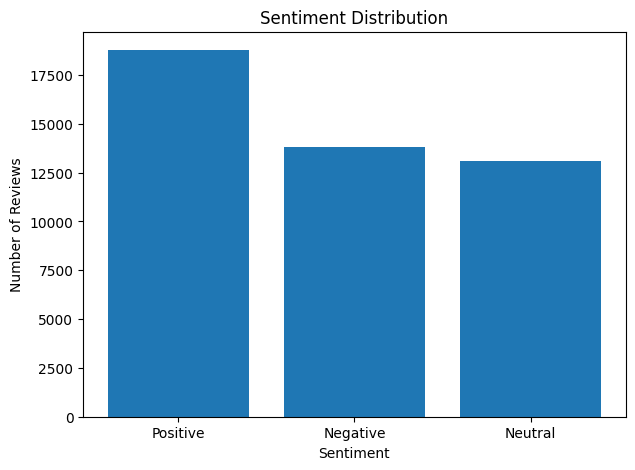

sentiment
Positive    18773
Negative    13787
Neutral     13087
Name: count, dtype: int64

In [6]:
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(7,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

sentiment_counts

## Observation

- Positive reviews represent the largest portion of the dataset.
- Negative and Neutral reviews are also well represented.
- The distribution is suitable for multi-class sentiment classification tasks.

# Rating Distribution

Customer ratings provide another perspective on user satisfaction. We examine how ratings are distributed across all reviews.

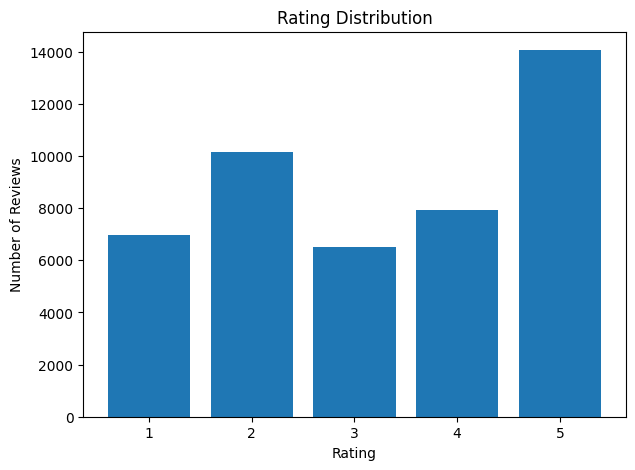

In [7]:
rating_counts = df["rating"].value_counts().sort_index()

plt.figure(figsize=(7,5))
plt.bar(rating_counts.index.astype(str), rating_counts.values)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

## Observation

- Ratings range from 1 to 5 stars.
- Higher ratings generally correspond to positive reviews.
- Lower ratings are primarily associated with negative sentiment.

# Product Category Distribution

This visualization shows how reviews are distributed across different product and service categories.

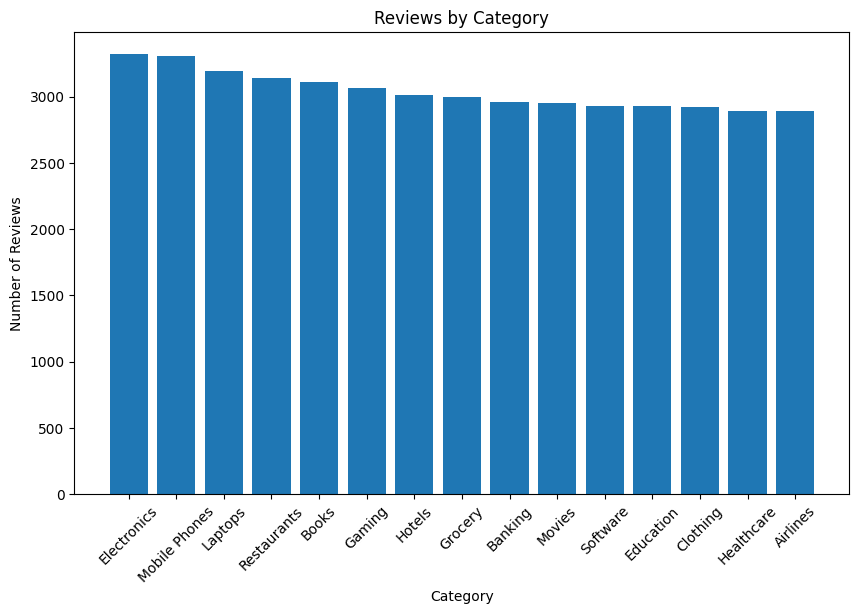

In [8]:
category_counts = df["category"].value_counts()

plt.figure(figsize=(10,6))
plt.bar(category_counts.index, category_counts.values)

plt.xticks(rotation=45)
plt.title("Reviews by Category")
plt.xlabel("Category")
plt.ylabel("Number of Reviews")

plt.show()

## Observation

- Reviews are distributed across 15 different domains.
- The category distribution is relatively balanced.
- This diversity makes the dataset suitable for domain-independent sentiment analysis.

# Country Distribution

This chart shows the geographical distribution of customer reviews across different countries.

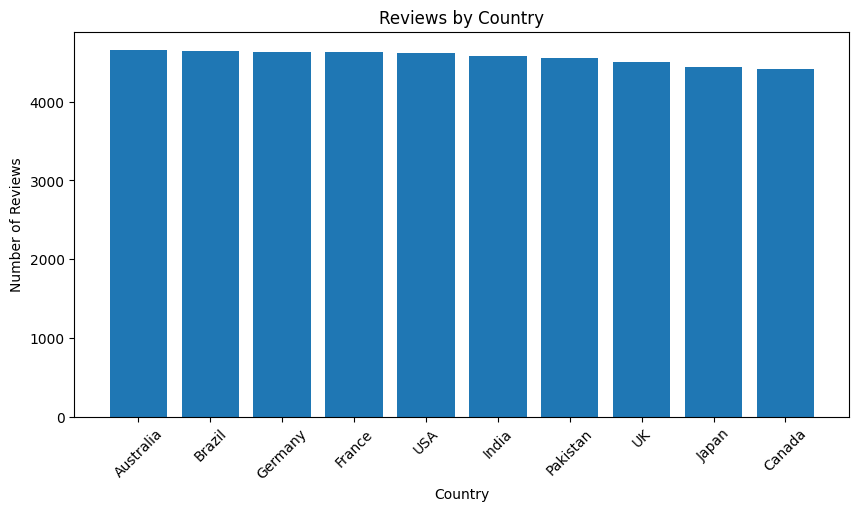

In [9]:
country_counts = df["country"].value_counts()

plt.figure(figsize=(10,5))
plt.bar(country_counts.index, country_counts.values)

plt.title("Reviews by Country")
plt.xlabel("Country")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)

plt.show()

## Observation

- Reviews are collected from multiple countries.
- The distribution is relatively balanced.
- This diversity makes the dataset useful for international customer feedback analysis.

# Device Distribution

Let's examine which devices customers used when submitting their reviews.

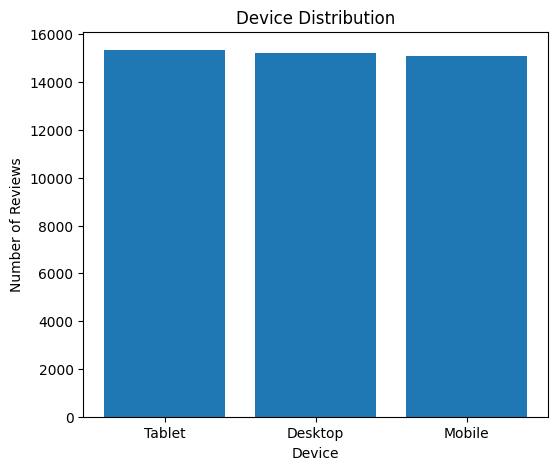

In [10]:
device_counts = df["device"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(device_counts.index, device_counts.values)

plt.title("Device Distribution")
plt.xlabel("Device")
plt.ylabel("Number of Reviews")

plt.show()

## Observation

- Reviews were submitted from Mobile, Desktop, and Tablet devices.
- Device usage is well distributed, making the dataset suitable for device-based analytics.

# Writing Style Distribution

The dataset contains reviews written in multiple writing styles to simulate realistic customer feedback.

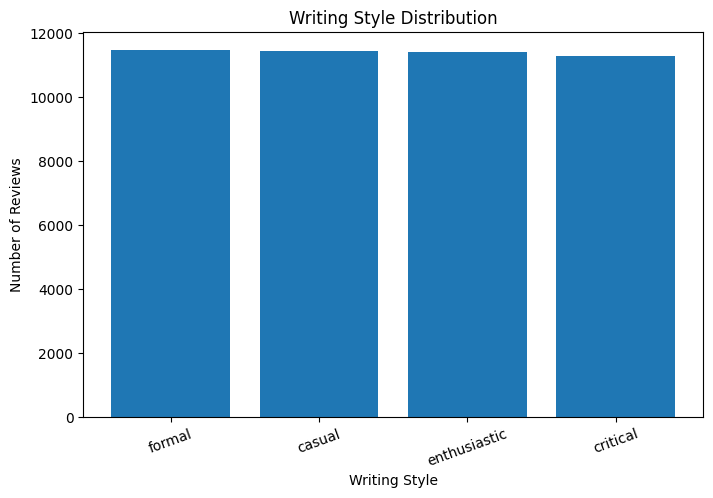

In [11]:
style_counts = df["writing_style"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(style_counts.index, style_counts.values)

plt.title("Writing Style Distribution")
plt.xlabel("Writing Style")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=20)

plt.show()

## Observation

- Reviews include Formal, Casual, Enthusiastic, and Critical writing styles.
- This variation increases linguistic diversity for NLP and text classification tasks.

# Emotion Distribution

Each review is associated with a dominant emotional tone derived from its sentiment.

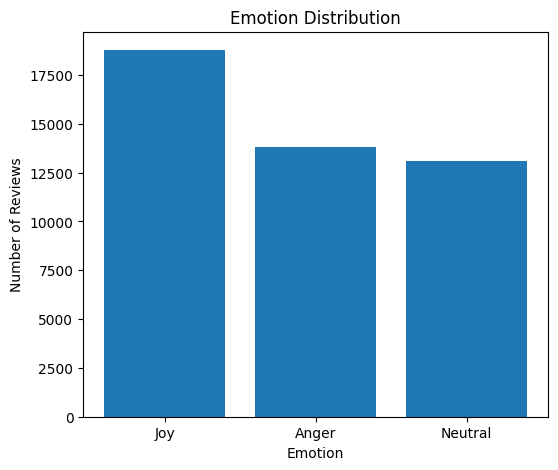

In [12]:
emotion_counts = df["emotion"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(emotion_counts.index, emotion_counts.values)

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Reviews")

plt.show()

## Observation

- Joy is the most common emotion due to the higher number of positive reviews.
- Anger corresponds primarily to negative reviews.
- Neutral emotion represents objective or balanced opinions.

# Review Length Distribution

Review length is an important feature in sentiment analysis and text mining. Here we analyze the number of words per review.

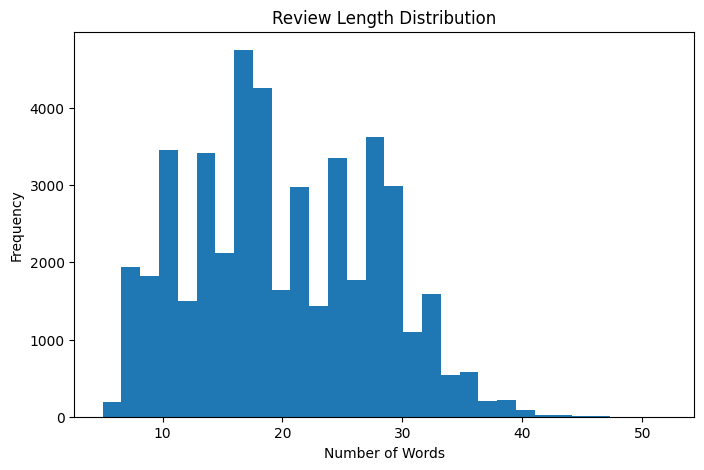

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["review_length"], bins=30)

plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

## Observation

- Review lengths vary from short to long.
- Most reviews contain a moderate number of words.
- The diversity in review length makes the dataset suitable for training NLP models that handle varying text sizes.

# Top 15 Most Reviewed Products

This visualization highlights the products that received the highest number of customer reviews.

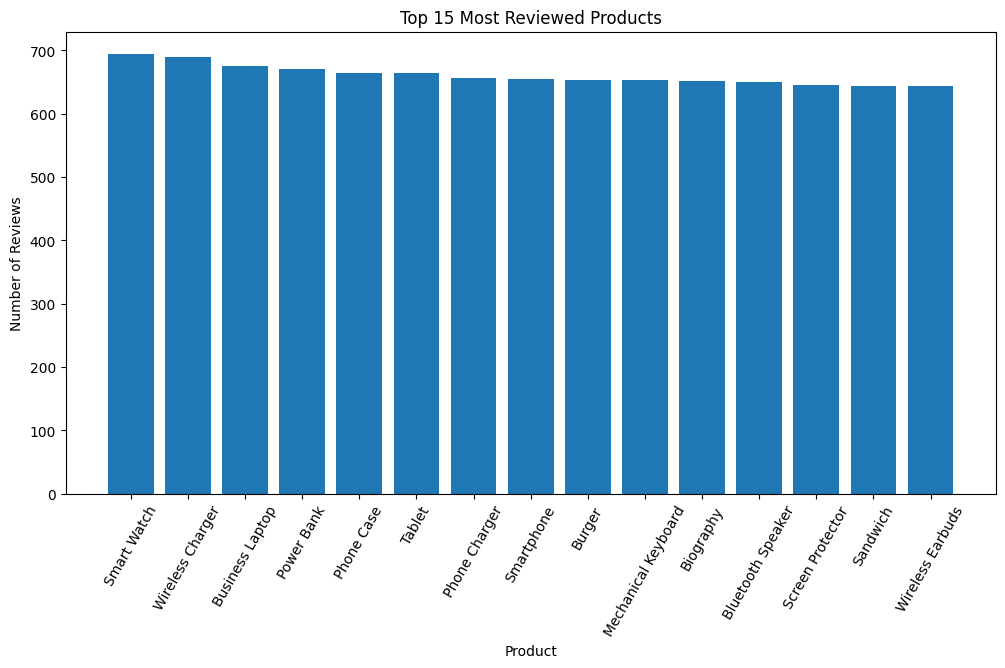

In [14]:
top_products = df["product"].value_counts().head(15)

plt.figure(figsize=(12,6))

plt.bar(top_products.index, top_products.values)

plt.xticks(rotation=60)

plt.title("Top 15 Most Reviewed Products")
plt.xlabel("Product")
plt.ylabel("Number of Reviews")

plt.show()

# Average Rating by Category

Customer ratings provide valuable insight into satisfaction levels across different product and service categories.

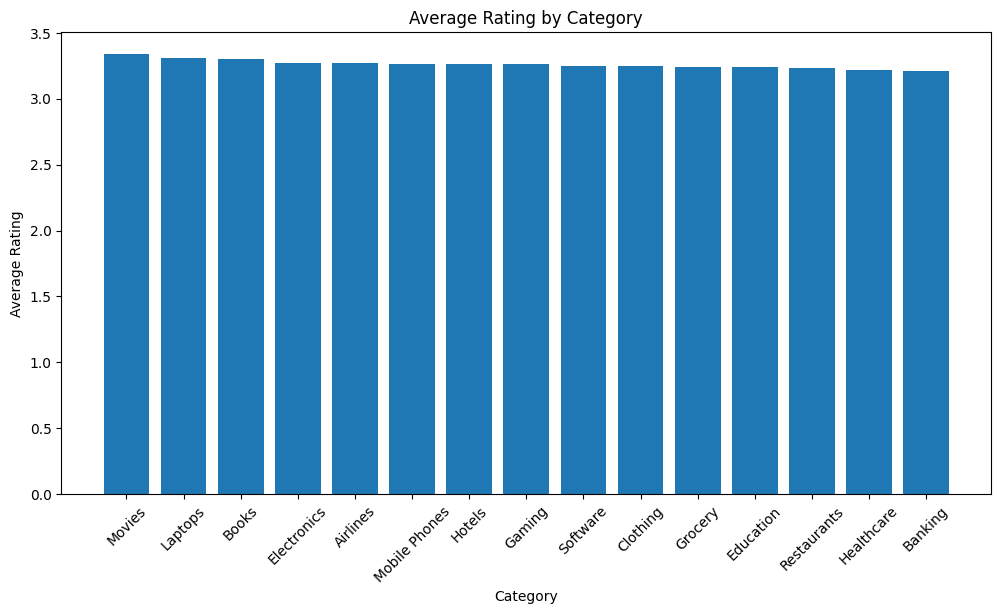

In [15]:
avg_rating = df.groupby("category")["rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

plt.bar(avg_rating.index, avg_rating.values)

plt.xticks(rotation=45)

plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")

plt.show()

# Sentiment vs Rating

This analysis examines the relationship between customer ratings and sentiment labels.

In [16]:
sentiment_rating = pd.crosstab(df["rating"], df["sentiment"])

sentiment_rating

sentiment,Negative,Neutral,Positive
rating,,,
1,6975,0,0
2,6812,3336,0
3,0,6531,0
4,0,3220,4702
5,0,0,14071


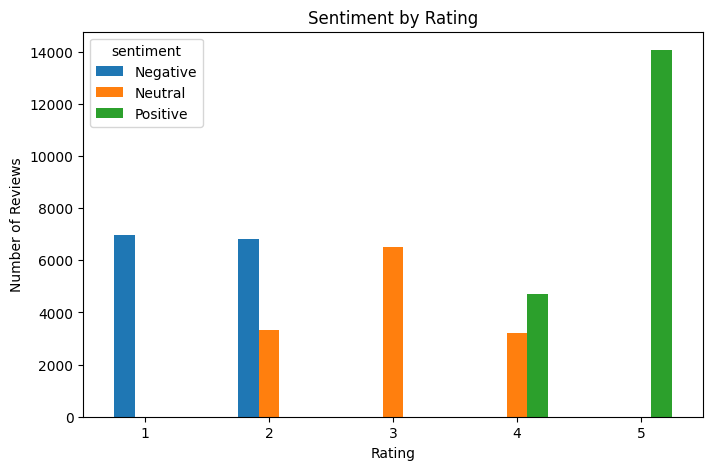

In [17]:
sentiment_rating.plot(kind="bar", figsize=(8,5))

plt.title("Sentiment by Rating")

plt.xlabel("Rating")

plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)

plt.show()

# Country vs Sentiment

This visualization compares sentiment distributions across different countries.

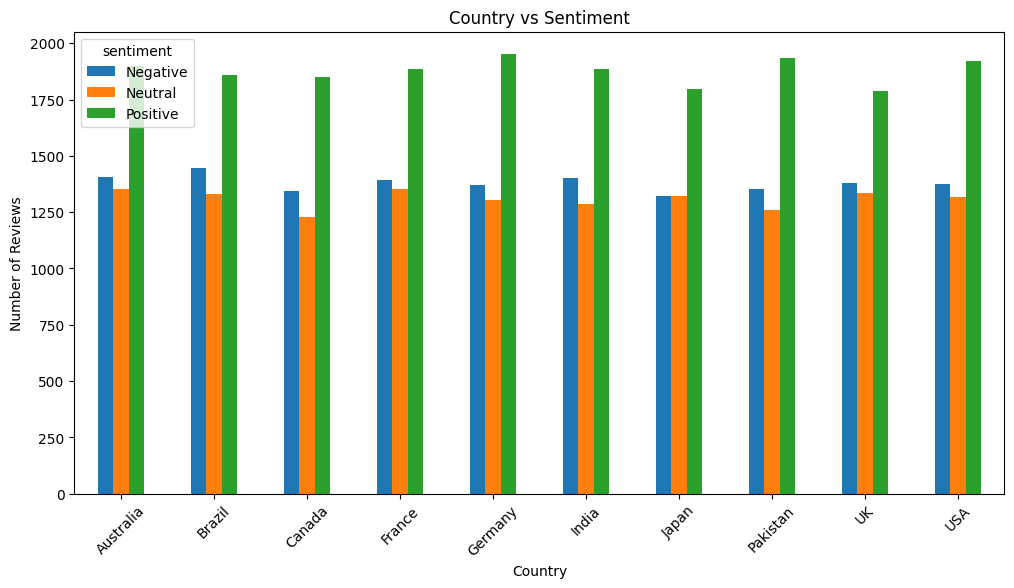

In [18]:
country_sentiment = pd.crosstab(df["country"], df["sentiment"])

country_sentiment.plot(kind="bar", figsize=(12,6))

plt.title("Country vs Sentiment")

plt.xlabel("Country")

plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)

plt.show()

# Correlation Analysis

Correlation analysis helps identify relationships between numerical features in the dataset.

In [19]:
numeric = df.select_dtypes(include=["int64","float64"])

corr = numeric.corr()

corr

,rating,helpful_votes,review_length,recommendation_score
rating,1.000000,0.003770,0.112181,0.877783
helpful_votes,0.003770,1.000000,-0.000177,0.004648
review_length,0.112181,-0.000177,1.000000,0.104653
recommendation_score,0.877783,0.004648,0.104653,1.000000


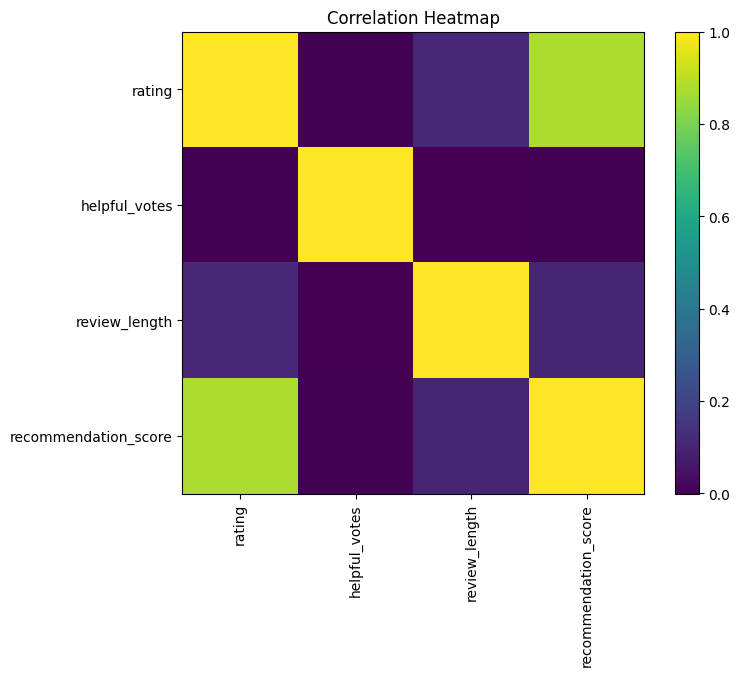

In [20]:
plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()

## Observation

- Most numerical features exhibit weak to moderate correlations.
- Ratings and recommendation scores show a positive relationship.
- The dataset contains a variety of relatively independent features, making it useful for machine learning experiments.

# Building a Baseline Sentiment Analysis Model

In this section, we build a baseline sentiment classification model using:

- TF-IDF Vectorization
- Logistic Regression
- Train/Test Split

This model demonstrates how the dataset can be used for Natural Language Processing (NLP) tasks.

In [21]:
from sklearn.preprocessing import LabelEncoder

X = df["review"]
y = df["sentiment"]

encoder = LabelEncoder()
y = encoder.fit_transform(y)

print(encoder.classes_)

['Negative' 'Neutral' 'Positive']


# Train-Test Split

The dataset is divided into training and testing sets to evaluate model performance on unseen data.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF Vectorization

The review text is transformed into numerical feature vectors using Term Frequency-Inverse Document Frequency (TF-IDF).

In [23]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Training Logistic Regression Model

We train a Logistic Regression classifier as a strong baseline model for sentiment analysis.

In [24]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

# Model Evaluation

Evaluate the trained model using accuracy, confusion matrix, and classification report.

In [25]:
predictions = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9986856516976998


In [26]:
print(classification_report(y_test, predictions,target_names=encoder.classes_))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      2758
     Neutral       1.00      1.00      1.00      2617
    Positive       1.00      1.00      1.00      3755

    accuracy                           1.00      9130
   macro avg       1.00      1.00      1.00      9130
weighted avg       1.00      1.00      1.00      9130



In [27]:
cm = confusion_matrix(y_test, predictions)

cm

array([[2748,    3,    7],
       [   0, 2615,    2],
       [   0,    0, 3755]])

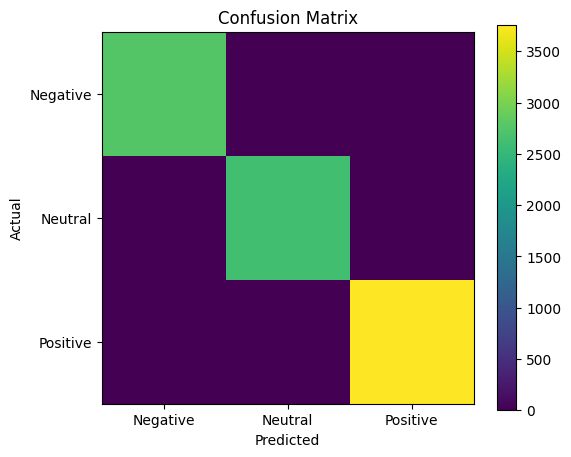

In [28]:
plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.colorbar()

plt.xticks(range(len(encoder.classes_)), encoder.classes_)

plt.yticks(range(len(encoder.classes_)), encoder.classes_)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# Testing on Custom Reviews

Let's test the trained model using new customer reviews that were not part of the dataset.

In [29]:
examples = [

    "This laptop is amazing and works perfectly.",

    "Worst purchase ever. Completely disappointed.",

    "The product is okay. Nothing special."

]

examples_vec = vectorizer.transform(examples)

pred = model.predict(examples_vec)

pred = encoder.inverse_transform(pred)

for review, sentiment in zip(examples, pred):

    print(review)

    print("Predicted Sentiment:", sentiment)

    print()

This laptop is amazing and works perfectly.
Predicted Sentiment: Positive

Worst purchase ever. Completely disappointed.
Predicted Sentiment: Negative

The product is okay. Nothing special.
Predicted Sentiment: Neutral



# Saving the Trained Model

To make the model reusable, we save the trained classifier, TF-IDF vectorizer, and label encoder. These files can later be uploaded as a Kaggle Model or integrated into web applications.

In [30]:
import joblib

joblib.dump(model, "sentiment_model.pkl")

joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

joblib.dump(encoder, "label_encoder.pkl")

print("Model files saved successfully!")

Model files saved successfully!


# Conclusion

In this notebook, we:

- Explored a synthetic dataset containing over **45,000 customer reviews**.
- Performed comprehensive exploratory data analysis (EDA).
- Analyzed sentiment, ratings, categories, countries, writing styles, and review lengths.
- Built a baseline sentiment classification model using TF-IDF and Logistic Regression.
- Evaluated the model using standard classification metrics.
- Saved the trained model, vectorizer, and label encoder for future inference and deployment.

This notebook demonstrates how the dataset can be used as a complete workflow for sentiment analysis, from data exploration to model training and serialization.